## Imports

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import shap
import pandas as pd
from sklearn.model_selection import train_test_split

In [15]:
# Load data
diabetes = pd.read_csv("data/diabetes_processed.csv")
ids = pd.read_csv("data/diabetes/IDS_mapping.csv")

In [ ]:
target_name = 'readmitted'

X = diabetes[[c for c in diabetes if c != target_name]].copy()
y = diabetes[target_name].copy()

# Protected attribute for fairness analysis
group = diabetes["gender"].astype(int)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X,
    y,
    group,
    test_size=0.2,
    random_state=0,
    stratify=y
)

In [221]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 81410 entries, 56843 to 64009
Data columns (total 55 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   patient_nbr                                     81410 non-null  int64
 1   gender                                          81410 non-null  int64
 2   age                                             81410 non-null  int64
 3   admission_type_id                               81410 non-null  int64
 4   discharge_disposition_id                        81410 non-null  int64
 5   admission_source_id                             81410 non-null  int64
 6   time_in_hospital                                81410 non-null  int64
 7   num_lab_procedures                              81410 non-null  int64
 8   num_procedures                                  81410 non-null  int64
 9   num_medications                                 81410 non-null  int64
 10

In [222]:
def print_classification_results(y_test, y_pred):
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

In [223]:
def get_log_reg_pipeline(
    seed: int = 70766,
    max_iter: int = 5000,
    penalty: str = 'l2',
    C: float = 0.8497534359086438,
    tol: float = 1e-4,
    solver: str = 'saga'
):
    scaler = StandardScaler() # Standard scale for log reg
    model = LogisticRegression(
        class_weight='balanced',
        penalty = penalty,
        C = C,
        random_state = seed,
        max_iter = max_iter,
        tol = tol,
        solver = solver
    )
    pipeline = Pipeline([('scaler', scaler), ('classifier', model)])
    return pipeline

In [224]:
# Get pipeline and fit to training data
log_reg = get_log_reg_pipeline()
log_reg.fit(X_train, y_train)

# Predict on test set
log_reg_y_pred = log_reg.predict(X_test)

# Evaluate
print_classification_results(y_test, log_reg_y_pred)

c:\Users\kubic\OneDrive\Dokumenty\envs\algotithmic_fairness\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy: 0.6669
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     18082
           1       0.17      0.51      0.25      2271

    accuracy                           0.67     20353
   macro avg       0.54      0.60      0.52     20353
weighted avg       0.83      0.67      0.73     20353



In [225]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, log_reg_y_pred))

[[12422  5660]
 [ 1119  1152]]


In [226]:
def get_scores_test(model, X_test):
    return model.predict_proba(X_test)[:, 1]

def make_selection(scores_test, thresholds: tuple = (.5, .5)):
    # Apply group-specific thresholds
    selections = np.zeros_like(scores_test)
    selections[group_test == 0] = (scores_test[group_test == 0] >= thresholds[0]).astype(int)
    selections[group_test == 1] = (scores_test[group_test == 1] >= thresholds[1]).astype(int)
    return selections

# Define function to evaluate fairness
def evaluate_fairness(S, T, G):
    df = pd.DataFrame({'S': S, 'T': T, 'G': G})

    results = {}
    for g in [0, 1]: # Male, Female
        subset = df[df['G'] == g]

        # Statistical/demographic parity P(S=1|G)
        results[f'G={g}_Selection_Rate'] = subset['S'].mean()

        # Equalized Odds P(S=1|G, T)
        results[f'G={g}_TPR'] = subset[subset['T'] == 1]['S'].mean()
        results[f'G={g}_FPR'] = subset[subset['T'] == 0]['S'].mean()

        # Equalized Outcome P(T=1|G, S)
        results[f'G={g}_Prec'] = subset[subset['S'] == 1]['T'].mean()
        results[f'G={g}_NPV'] = subset[subset['S'] == 0]['T'].mean()

    return results

def print_fairness_overiew(fairness_metrics: dict, epsilon: float = 1e-3):
    # Statistical parity
    print('Statistical Parity:')
    g1_selection_rate = fairness_metrics['G=0_Selection_Rate']
    g2_selection_rate = fairness_metrics['G=1_Selection_Rate']
    print(f'Group 0 Selection Rate P(S=1|G=0): {g1_selection_rate:.4f}')
    print(f'Group 1 Selection Rate P(S=1|G=1): {g2_selection_rate:.4f}')
    if abs(g1_selection_rate - g2_selection_rate) < epsilon:
        print('Statistical parity (approximately) achieved.')
    else:
        print('Statistical parity not achieved.')
    print('')

    # Equalized Odds
    print('Equalized Odds:')
    g0_tpr = fairness_metrics['G=0_TPR']
    g1_tpr = fairness_metrics['G=1_TPR']
    g0_fpr = fairness_metrics['G=0_FPR']
    g1_fpr = fairness_metrics['G=1_FPR']

    print(f'Group 0 True Positive Rate P(S=1|G=0,T=1): {g0_tpr:.4f}')
    print(f'Group 1 True Positive Rate P(S=1|G=1,T=1): {g1_tpr:.4f}')

    print(f'Group 0 False Positive Rate P(S=1|G=0,T=0): {g0_fpr:.4f}')
    print(f'Group 1 False Positive Rate P(S=1|G=1,T=0): {g1_fpr:.4f}')
    if abs(g0_tpr - g1_tpr) < epsilon and abs(g0_fpr - g1_fpr) < epsilon:
        print('Equalized odds (approximately) achieved.')
    else:
        print('Equalized odds not achieved.')

def plot_fairness_metrics(fairness_metrics: dict, scores_test, roc_cross: tuple = None):
    _, axes = plt.subplots(1, 2, figsize = (12, 6))

    # ROC curve
    for g, label in zip([0, 1], ['Group 0', 'Group 1']):
        idx = group_test == g
        fpr, tpr, _ = roc_curve(y_test[idx], scores_test[idx])
        axes[0].plot(fpr, tpr, label=label)

    if roc_cross is not None:
        axes[0].scatter([roc_cross[0]], [roc_cross[1]], marker = 'x', color = 'red', s = 100)

    axes[0].grid(True, linestyle = '--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve by Group')
    axes[0].legend()

    # Bar plot
    groups = ['Group 0', 'Group 1']
    selection_rates = [fairness_metrics['G=0_Selection_Rate'], fairness_metrics['G=1_Selection_Rate']]
    axes[1].bar(groups, selection_rates)
    axes[1].set_ylabel('Selection Rate')
    axes[1].set_title('Selection Rate by Group')
    plt.show()

Statistical Parity:
Group 0 Selection Rate P(S=1|G=0): 0.3501
Group 1 Selection Rate P(S=1|G=1): 0.3164
Statistical parity not achieved.

Equalized Odds:
Group 0 True Positive Rate P(S=1|G=0,T=1): 0.5151
Group 1 True Positive Rate P(S=1|G=1,T=1): 0.4981
Group 0 False Positive Rate P(S=1|G=0,T=0): 0.3295
Group 1 False Positive Rate P(S=1|G=1,T=0): 0.2934
Equalized odds not achieved.


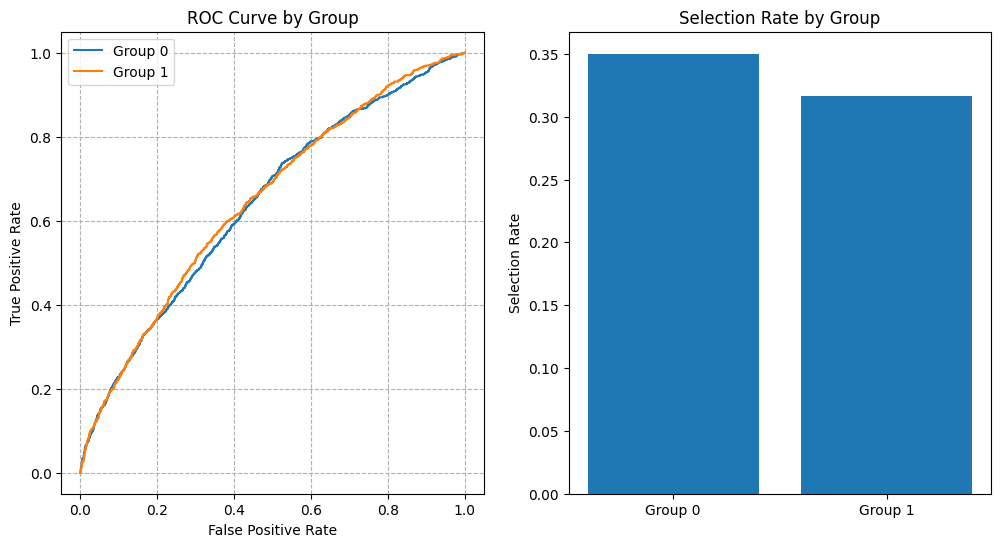

In [227]:
# Get test scores and make selections
log_reg_scores_test = get_scores_test(log_reg, X_test)
log_reg_selections = make_selection(log_reg_scores_test)
log_reg_fairness_metrics = evaluate_fairness(log_reg_selections, y_test, group_test)
print_fairness_overiew(log_reg_fairness_metrics)
plot_fairness_metrics(log_reg_fairness_metrics, log_reg_scores_test)